以下の関数が0となる解を、ニュートン法を用いて求めてみましょう。

In [12]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [13]:
def f(x):
    return x**3 + 2*x + 1

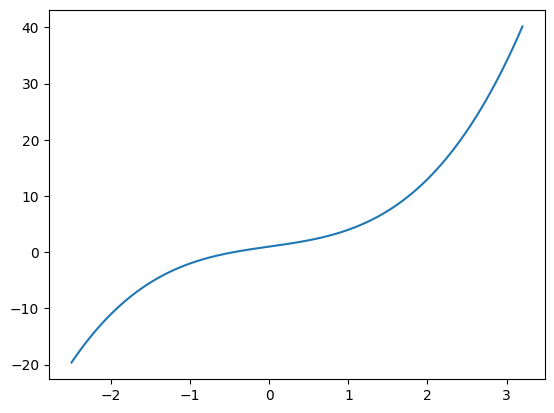

In [14]:
xlist=np.linspace(-2.5,3.2,100)
ylist=f(xlist)
plt.plot(xlist,ylist)

初期値: [-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2.   2.5  3. ]
求まった根: [-0.45339765]
f(root)= 3.967986383912603e-09


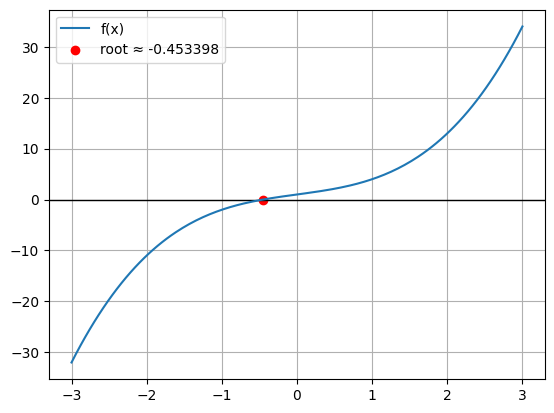

In [17]:

# シンボル定義
x_sym = sp.Symbol('x')
f_sym = x_sym**3 + 2*x_sym + 1

# 関数の導関数を計算
f_prime = sp.diff(f_sym, x_sym)

# NumPyの関数に変換
fx = sp.lambdify(x_sym, f_sym, 'numpy')
fprime = sp.lambdify(x_sym, f_prime, 'numpy')

# ニュートン法による零点探索
def newton_root(x0, tol=1e-8, max_iter=50):
    x = x0
    for _ in range(max_iter):
        fx_val = fx(x)
        fprime_val = fprime(x)
        if np.abs(fprime_val) < 1e-12:
            break
        x_next = x - fx_val / fprime_val
        if np.abs(fx(x_next)) < tol:
            return x_next
        x = x_next
    return x

# いくつかの初期値で探す
initial_guesses = np.linspace(-3, 3, 13)
roots = [newton_root(x0) for x0 in initial_guesses]
unique_roots = np.unique(np.round(roots, 8))

print('初期値:', initial_guesses)
print('求まった根:', unique_roots)

# 代表的な根を表示
root = unique_roots[0]
print('f(root)=', fx(root))

# 結果のプロット
x_vals = np.linspace(-3, 3, 200)
y_vals = fx(x_vals)
plt.axhline(0, color='black', linewidth=1)
plt.plot(x_vals, y_vals, label='f(x)')
plt.scatter([root], [0], color='red', label=f'root ≈ {root:.6f}')
plt.legend()
plt.grid(True)
plt.show()
